In [2]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
netid = "jp2249"
bucket_name = f"dsan6000-{netid}"
s3 = boto3.client("s3")

In [ ]:
resp=s3.list_objects_v2(Bucket=bucket_name, Prefix="wikipedia-hourly/")
keys = sorted(obj["Key"] for obj in resp["Contents"])
hourly_dfs = []
for key in keys:
    uri = f"s3://{bucket_name}/{key}"
    hourly_dfs.append(pd.read_parquet(uri))
df = pd.concat(hourly_dfs, ignore_index=True)
df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


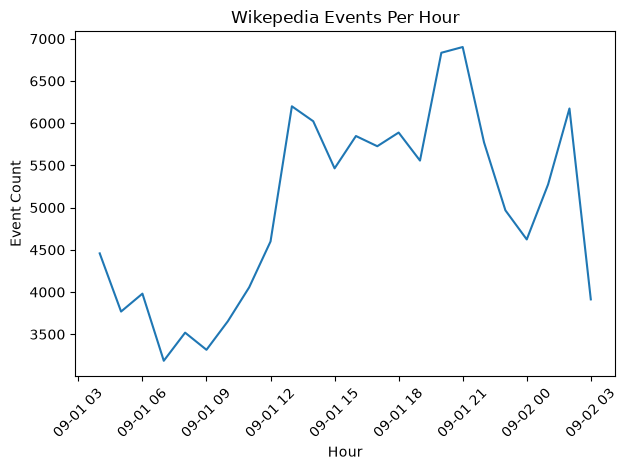

In [8]:
df["hour"] = pd.to_datetime(df["datetime"]).dt.floor("h")
hourly_counts = df.groupby("hour").size().reset_index(name="event_count")
sns.lineplot(data=hourly_counts, x="hour", y="event_count")
plt.title("Wikepedia Events Per Hour")
plt.xlabel("Hour")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")
plt.show()

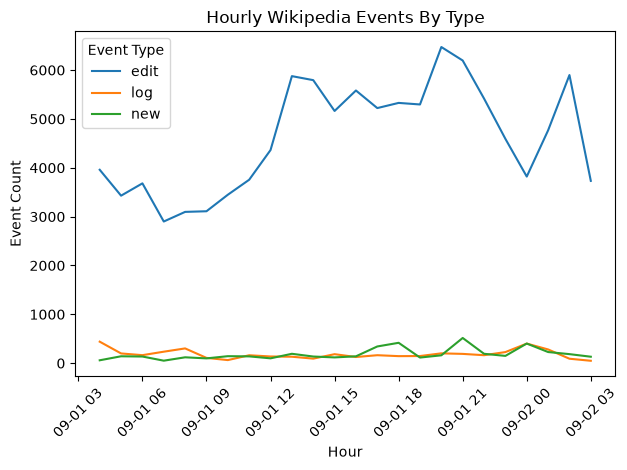

In [11]:
type_counts = df.groupby(["hour", "type"]).size().reset_index(name="event_count")
sns.lineplot(data=type_counts, x="hour", y="event_count", hue="type")
plt.title("Hourly Wikipedia Events By Type")
plt.xlabel("Hour")
plt.ylabel("Event Count")
plt.legend(title = "Event Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")
plt.show()